In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# BCELoss

## reduction='sum'

In [15]:
loss_fn = nn.BCELoss(reduction='sum')

In [16]:
x = torch.rand(5) # input, values [0,1]
y = torch.rand(5) # target, values [0,1]
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    s -= (y_i * torch.log(x_i) + (1 - y_i) * torch.log(1 - x_i))

loss, s

(tensor(4.3156), tensor(4.3156))

In [17]:
x = torch.rand((3, 10))
y = torch.rand((3, 10))
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    for x_i_j, y_i_j in zip(x_i, y_i):
        s -= (y_i_j * torch.log(x_i_j) + (1 - y_i_j) * torch.log(1 - x_i_j))

loss, s

(tensor(30.3374), tensor(30.3374))

## reduction="mean"

In [18]:
loss_fn = nn.BCELoss(reduction='mean')

In [19]:
x = torch.rand(5) # input, values [0,1]
y = torch.rand(5) # target, values [0,1]
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    s -= (y_i * torch.log(x_i) + (1 - y_i) * torch.log(1 - x_i))

loss, s / len(x)

(tensor(1.5379), tensor(1.5379))

In [20]:
x = torch.rand((3, 10))
y = torch.rand((3, 10))
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    for x_i_j, y_i_j in zip(x_i, y_i):
        s -= (y_i_j * torch.log(x_i_j) + (1 - y_i_j) * torch.log(1 - x_i_j))

loss, s / len(x.ravel())

(tensor(0.9407), tensor(0.9407))

Для BCELoss(reduction='mean') и входных данных в виде набора векторов (матрица), мы получаем что ошибка усредняется по всей матрицы, а не по-векторно

## reduction='none'

In [21]:
inputs = torch.tensor([0.0, 0.01, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0])
targets = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
nn.BCELoss(reduction='none')(inputs, targets)

tensor([100.0000,   4.6052,   2.3026,   1.6094,   0.9163,   0.5108,   0.2231,
          0.1054,  -0.0000])

In [22]:
inputs = torch.tensor([0.0, 0.01, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 1.0])
targets = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
nn.MSELoss(reduction='none')(inputs, targets)

tensor([1.0000, 0.9801, 0.8100, 0.6400, 0.3600, 0.1600, 0.0400, 0.0100, 0.0000])

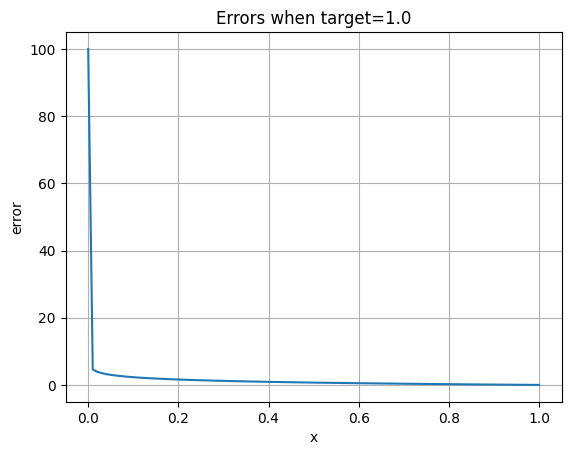

In [23]:
inputs = torch.linspace(0, 1, 100)
targets = torch.ones_like(inputs)
plt.plot(inputs, nn.BCELoss(reduction='none')(inputs, targets));
plt.xlabel('x')
plt.ylabel('error')
plt.title(f'Errors when target={targets[0]}')
plt.grid();

In [24]:
inputs = torch.tensor([0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0])
targets = torch.tensor([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])
nn.BCELoss(reduction='none')(inputs, targets)

tensor([50.0000,  1.2040,  0.7803,  0.6931,  0.7803,  1.2040, 50.0000])

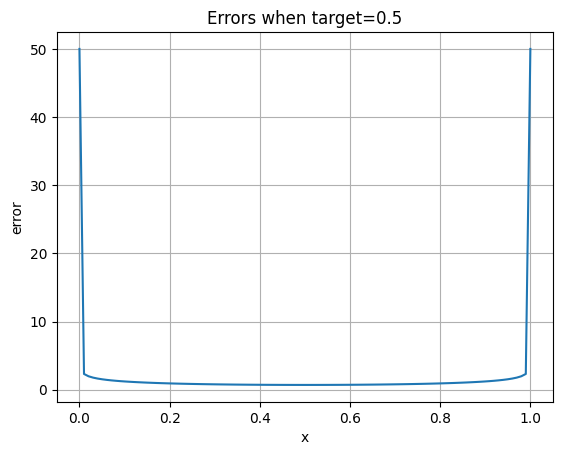

In [25]:
inputs = torch.linspace(0, 1, 100)
targets = torch.full_like(inputs, 0.5)
plt.plot(inputs, nn.BCELoss(reduction='none')(inputs, targets))
plt.xlabel('x')
plt.ylabel('error')
plt.title(f'Errors when target={targets[0]}')
plt.grid();

1) BCELoss штрафует по закону, напоминающему децибельный. Разница x10 в input штрафуется в два раза ниже. x=0.01, y=1 => штраф=4.6, x=0.1, y=1 => штраф=2.3
2) штрафуются очень сильно ярко выраженные промахи. Т.е. если x=0, y=1 или x=1, y=0. Тут прям очень сильно бьют. Дескать если уж идёшь ва-банк (x=0 или x=1), то будь уверен на все 100.
3) если y между 0 и 1, то значения штрафа=0 достигнуть в принципе невозможно, т.е. BCELoss(y,y)>0, когда 0 < y < 14) 

# BCEWithLogitsLoss

In [26]:
loss_fn = nn.BCEWithLogitsLoss(reduction='sum')

In [27]:
x = torch.randn(10) # input, both negative and positive values
y = torch.rand(10) # target, contains values [0,1]
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    s -= (y_i * torch.log(F.sigmoid(x_i)) + (1 - y_i) * torch.log(1 - F.sigmoid(x_i)))

loss, s

(tensor(7.4504), tensor(7.4504))

In [28]:
x = torch.randn((3, 10))
y = torch.rand((3, 10))
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    for x_i_j, y_i_j in zip(x_i, y_i):
        s -= (y_i_j * torch.log(F.sigmoid(x_i_j)) + (1 - y_i_j) * torch.log(1 - F.sigmoid(x_i_j)))

loss, s

(tensor(25.3850), tensor(25.3850))

# BCELoss vs CrossEntropyLoss

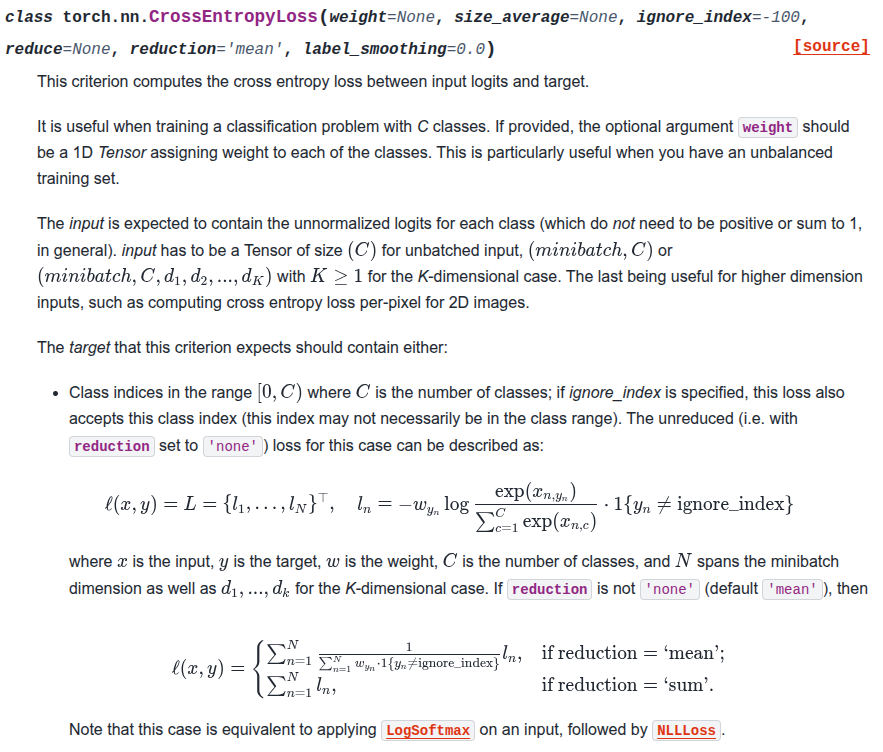
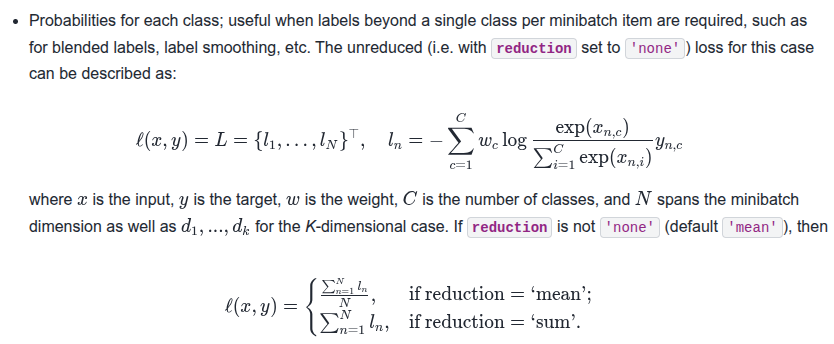

In [39]:
bce_loss = nn.BCELoss()
ce_loss = nn.CrossEntropyLoss()

x = torch.rand(5) # input, values [0,1]
y = torch.rand(5) # target, values [0,1]
x2 = torch.zeros(1, 2, len(x)) # minibatch, 2 Classes, vector itself

for x_ind, x_i in enumerate(x):
    # taking logs on X to compensate softmax done by CrossEntropyLoss
    x2[0,0,x_ind] = torch.log(x_i) 
    x2[0,1,x_ind] = torch.log(1 - x_i)

y2 = torch.zeros(1, 2, len(y)) # minibatch, 2 Classes, vector itself

for y_ind, y_i in enumerate(y):
    y2[0,0,y_ind] = y_i
    y2[0,1,y_ind] = 1 - y_i

bce_loss(x, y), ce_loss(x2, y2)

(tensor(1.1511), tensor(1.1511))

BCELoss есть частный случай CrossEntropyLoss, когда есть только 2 класса и когда данные (x) уже в виде вероятностей идут (не надо делать softmax)

# BCELoss vs MSELoss

In [75]:
bce_loss = nn.BCELoss()
mse_loss = nn.MSELoss()

xx, yy = np.meshgrid(np.linspace(0.01, 0.99, 100), np.linspace(0.01, 0.99, 100))
xx = torch.Tensor(xx)
yy = torch.Tensor(yy)
bce_zz = []
mse_zz = []

for x, y in zip(xx.ravel(), yy.ravel()):
    bce_zz.append(bce_loss(x, y))
    mse_zz.append(mse_loss(x, y))

bce_zz = np.array(bce_zz).reshape(xx.shape)
mse_zz = np.array(mse_zz).reshape(xx.shape)

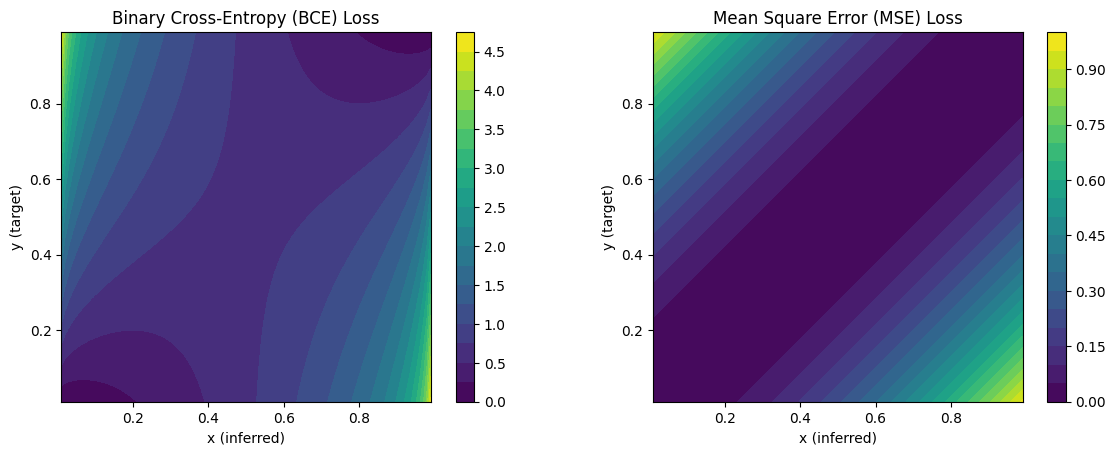

In [76]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(14)

im = ax1.contourf(xx, yy, bce_zz, levels=20, cmap='viridis')
ax1.set_aspect('equal')
ax1.set_xlabel('x (inferred)')
ax1.set_ylabel('y (target)')
ax1.set_title('Binary Cross-Entropy (BCE) Loss')
fig.colorbar(im, ax=ax1);

im = ax2.contourf(xx, yy, mse_zz, levels=20, cmap='viridis')
ax2.set_aspect('equal')
ax2.set_xlabel('x (inferred)')
ax2.set_ylabel('y (target)')
ax2.set_title('Mean Square Error (MSE) Loss')
fig.colorbar(im, ax=ax2);

1) Пр сравнению с MSE BCE растёт гораздо быстрее.
2) когда ошибка в классификации наиболее сильная (например, 1 vs 0), то штраф просто космический получается, тогда как в MSE он ограничен единичкой.
3) эффект от BCE такой, что модель в первую очередь научается избегать сильные расхождения (типа 1 vs 0.2), а мелкие расхождения уже во вторую или третью очередь (типа 1 vs 0.8). MSЕ менее акцентен в этом плане, т.к. максимальный штраф 1.

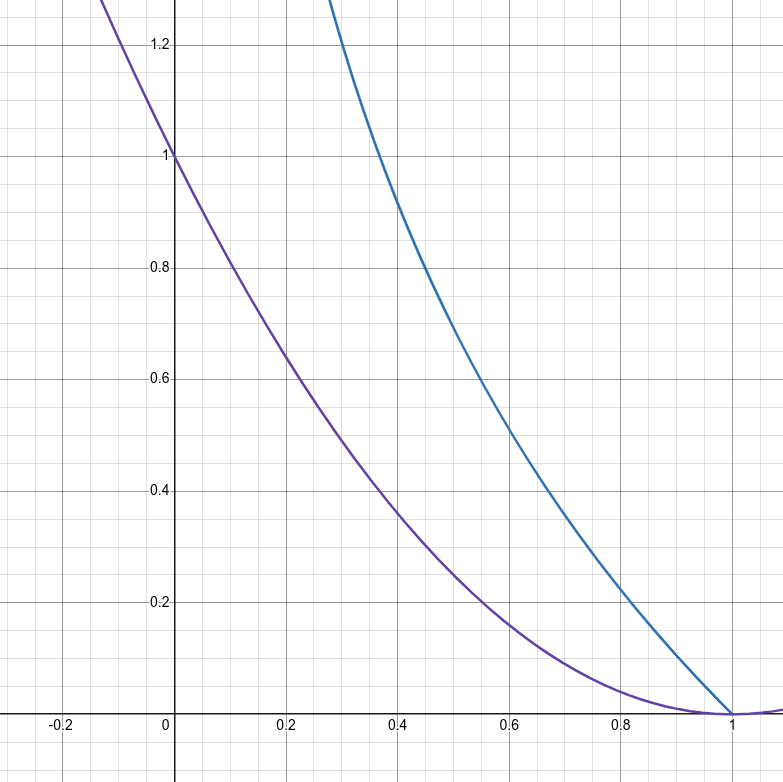